# 03 · Clasificación en BI — Predicción de Abandono de Clientes
## TechStore Perú S.A.C. — Programa de Fidelización

**Curso:** Inteligencia de Negocios · UNMSM — FISI
**Notebook:** `03_clasificacion.ipynb`

Este notebook construye y evalúa un modelo supervisado de clasificación para predecir el **abandono (churn)** de clientes del programa de fidelización de TechStore Perú S.A.C., siguiendo la metodología de la Guía de Laboratorio Semana 10 (Árbol de Decisión, Random Forest y Regresión Logística) aplicada al datamart propio del proyecto (`Dim_Cliente`, `Dim_Producto`, `Dim_Tienda`, `Dim_Promocion`, `Dim_Tiempo`, `Fact_Ventas`).

**Estructura del notebook:**
1. Carga del datamart (`data/processed/`).
2. Definición del problema y de la variable objetivo `abandono`.
3. Feature engineering: tabla analítica por cliente (antigüedad, frecuencia, monto, recencia, categorías, uso de promociones).
4. Análisis exploratorio de datos (EDA).
5. Preprocesamiento (encoding, división train/test estratificada 75/25).
6. Entrenamiento y evaluación de 3 modelos: Regresión Logística, Árbol de Decisión y Random Forest.
7. Comparación de modelos.
8. Importancia de variables e interpretación de negocio.
9. Validación cruzada estratificada.
10. Scoring de toda la base de clientes y exportación de `predicciones_abandono.csv` a `data/processed/` (insumo para Power BI).

**Ruta de datos:** este notebook asume que vive en una carpeta `notebook/` y que el datamart está en `../data/processed/` (un nivel arriba, dentro de `data/processed/`), tal como se indica en el enunciado del proyecto.

## 1. Configuración inicial
Importamos las librerías de análisis (`pandas`, `numpy`), visualización (`matplotlib`, `seaborn`) y modelado (`scikit-learn`). Fijamos la semilla `SEED = 42` para que la división de datos y el entrenamiento de los modelos sean reproducibles, y definimos las rutas de datos (`../data/processed`) y de figuras (`figuras/`, se crea si no existe).

In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    classification_report, confusion_matrix, roc_auc_score,
    RocCurveDisplay, ConfusionMatrixDisplay, accuracy_score,
    precision_score, recall_score, f1_score,
)

SEED = 42
np.random.seed(SEED)

DATA_DIR = "../data/processed"
FIG_DIR = "figuras"
os.makedirs(FIG_DIR, exist_ok=True)

print("Librerias cargadas correctamente.")


Librerias cargadas correctamente.


## 2. Carga del datamart
Cargamos las 6 tablas del datamart ya limpio (resultado del proceso ETL previo) desde `../data/processed/`. Estas tablas ya no tienen duplicados, nulos ni claves huérfanas (ver `reporte_auditoria_etl.txt`), por lo que este notebook se enfoca en la construcción de variables (*feature engineering*) y el modelado.

In [2]:
# =================================================================
# 1. CARGA DEL DATAMART
# =================================================================
dim_cliente = pd.read_csv(f"{DATA_DIR}/dim_cliente.csv", parse_dates=["fecha_nacimiento", "fecha_alta"])
dim_producto = pd.read_csv(f"{DATA_DIR}/dim_producto.csv")
dim_tienda = pd.read_csv(f"{DATA_DIR}/dim_tienda.csv")
dim_promocion = pd.read_csv(f"{DATA_DIR}/dim_promocion.csv")
dim_tiempo = pd.read_csv(f"{DATA_DIR}/dim_tiempo.csv", parse_dates=["fecha"])
fact_ventas = pd.read_csv(f"{DATA_DIR}/fact_ventas.csv", parse_dates=["fecha"])

print("dim_cliente:", dim_cliente.shape)
print("dim_producto:", dim_producto.shape)
print("dim_tienda:", dim_tienda.shape)
print("dim_promocion:", dim_promocion.shape)
print("dim_tiempo:", dim_tiempo.shape)
print("fact_ventas:", fact_ventas.shape)


dim_cliente: (5000, 7)
dim_producto: (500, 7)
dim_tienda: (15, 5)
dim_promocion: (41, 6)
dim_tiempo: (730, 7)
fact_ventas: (59700, 12)


## 3. Definición del problema y de la variable objetivo
**Problema de negocio:** anticipar qué clientes del programa de fidelización tienen alta probabilidad de abandonar (dejar de comprar), para que el equipo comercial pueda ejecutar acciones de retención dirigidas.

**Definición de `abandono`:** `abandono = 1` si el cliente no ha realizado ninguna compra en los últimos `N_DIAS_INACTIVIDAD` (90 días ≈ 3 meses) contados desde la fecha más reciente registrada en `Fact_Ventas`; `abandono = 0` en caso contrario. Los clientes que nunca compraron también se consideran en riesgo: se usa su antigüedad en el programa (`fecha_alta`) como proxy de su inactividad total.

Este umbral (`N_DIAS_INACTIVIDAD`) es un parámetro de negocio: puede ajustarse fácilmente cambiando su valor si el área comercial define otro criterio de "abandono".

In [3]:
# =================================================================
# 2. DEFINICION DEL PROBLEMA Y VARIABLE OBJETIVO
# =================================================================
# abandono = 1 si el cliente NO ha comprado en los ultimos N_DIAS_INACTIVIDAD
# dias, tomando como fecha de referencia la fecha mas reciente registrada
# en Fact_Ventas. Los clientes que nunca compraron tambien se consideran
# en riesgo (recencia = antiguedad desde su fecha de alta al programa).
N_DIAS_INACTIVIDAD = 90

fecha_referencia = fact_ventas["fecha"].max()
print("Fecha de referencia (ultima fecha en Fact_Ventas):", fecha_referencia.date())


Fecha de referencia (ultima fecha en Fact_Ventas): 2025-12-30


## 4. Feature engineering: tabla analítica por cliente
Construimos una tabla a nivel de **cliente** (una fila por `id_cliente`) agregando el comportamiento de compra registrado en `Fact_Ventas`:

- **Frecuencia:** número de líneas de venta (`frecuencia_compras`), unidades totales compradas.
- **Monetario:** monto acumulado, margen acumulado y ticket promedio.
- **Recencia:** días desde la última compra (o desde el alta, si nunca compró).
- **Diversidad de canasta:** número de tiendas distintas visitadas y de categorías distintas de producto compradas.
- **Uso de promociones:** número y porcentaje de líneas de compra con una promoción activa.
- **Antigüedad y edad:** derivadas de `fecha_alta` y `fecha_nacimiento`.

Esta es la lógica **RFM** (Recencia, Frecuencia, Monetario) extendida con variables propias del negocio de retail tecnológico (categorías, promociones, canal). Los clientes sin ninguna compra registrada se incluyen igualmente (con sus agregados en 0), ya que también forman parte de la base a evaluar para retención.

In [4]:
# =================================================================
# 3. FEATURE ENGINEERING: TABLA ANALITICA POR CLIENTE
# =================================================================
# 3.1 Agregados de comportamiento de compra (a nivel de linea de venta)
agg_cliente = fact_ventas.groupby("id_cliente").agg(
    frecuencia_compras=("id_venta", "count"),
    monto_acumulado=("importe", "sum"),
    margen_acumulado=("margen", "sum"),
    ticket_promedio_raw=("importe", "mean"),
    ultima_compra=("fecha", "max"),
    primera_compra=("fecha", "min"),
    tiendas_distintas=("id_tienda", "nunique"),
    unidades_totales=("cantidad", "sum"),
    lineas_con_promocion=("id_promocion", lambda s: (s != 0).sum()),
).reset_index()

agg_cliente["pct_compras_con_promocion"] = (
    agg_cliente["lineas_con_promocion"] / agg_cliente["frecuencia_compras"]
)

# 3.2 Categorias distintas compradas por cliente (afinidad de catalogo)
fv_categoria = fact_ventas.merge(
    dim_producto[["id_producto", "categoria"]], on="id_producto", how="left"
)
categorias_distintas = (
    fv_categoria.groupby("id_cliente")["categoria"].nunique().rename("categorias_distintas")
)
agg_cliente = agg_cliente.merge(categorias_distintas, on="id_cliente", how="left")

# 3.3 Union con Dim_Cliente (incluye tambien a quienes nunca compraron)
tabla_clientes = dim_cliente.merge(agg_cliente, on="id_cliente", how="left")

cols_sin_compras = [
    "frecuencia_compras", "monto_acumulado", "margen_acumulado", "ticket_promedio_raw",
    "tiendas_distintas", "unidades_totales", "lineas_con_promocion",
    "pct_compras_con_promocion", "categorias_distintas",
]
tabla_clientes[cols_sin_compras] = tabla_clientes[cols_sin_compras].fillna(0)
tabla_clientes = tabla_clientes.rename(columns={"ticket_promedio_raw": "ticket_promedio"})

# 3.4 Variables de tiempo: antiguedad, edad y recencia
tabla_clientes["antiguedad_dias"] = (fecha_referencia - tabla_clientes["fecha_alta"]).dt.days
tabla_clientes["edad"] = (
    (fecha_referencia - tabla_clientes["fecha_nacimiento"]).dt.days / 365.25
).astype(int)

# Recencia: dias desde la ultima compra. Si el cliente nunca compro, se usa
# su antiguedad en el programa como proxy de inactividad total.
tabla_clientes["recencia_dias"] = (fecha_referencia - tabla_clientes["ultima_compra"]).dt.days
tabla_clientes["recencia_dias"] = tabla_clientes["recencia_dias"].fillna(
    tabla_clientes["antiguedad_dias"]
)

# 3.5 Variable objetivo
tabla_clientes["abandono"] = (
    tabla_clientes["recencia_dias"] > N_DIAS_INACTIVIDAD
).astype(int)

tabla_clientes = tabla_clientes.drop(columns=["ultima_compra", "primera_compra"])

print("Tabla analitica de clientes:", tabla_clientes.shape)
print(tabla_clientes.head())


Tabla analitica de clientes: (5000, 20)
   id_cliente                         nombre sexo fecha_nacimiento   distrito  \
0           1           Albano Llopis Hierro    M       1962-05-05     Callao   
1           2          Berta Calatayud Bonet    F       1976-08-30  Magdalena   
2           3  Ileana Alejandra Andrés Bueno    F       1978-01-02      Lince   
3           4              Cruz Vazquez Amor    F       1998-03-08   Barranco   
4           5          Conrado Rivas-Giménez    M       1995-08-18     Callao   

  fecha_alta segmento_programa  frecuencia_compras  monto_acumulado  \
0 2022-03-01               Oro                 1.0           386.52   
1 2023-11-03            Bronce                 1.0         11040.52   
2 2025-10-16               Oro                 0.0             0.00   
3 2021-02-08             Plata                 0.0             0.00   
4 2021-03-22             Plata                52.0         84457.63   

   margen_acumulado  ticket_promedio  tiendas_

## 5. Análisis exploratorio de datos (EDA)
Verificamos la ausencia de nulos en la tabla analítica, revisamos estadísticas descriptivas de las variables numéricas clave y examinamos el balance de la variable objetivo `abandono`.


Valores nulos por columna:
Series([], dtype: int64)

Estadisticas descriptivas:
          edad  antiguedad_dias  frecuencia_compras  monto_acumulado  \
count  5000.00          5000.00             5000.00          5000.00   
mean     43.64           929.21               11.94         44809.41   
std      15.35           528.47               48.81        279456.29   
min      17.00             6.00                0.00             0.00   
25%      30.00           481.00                1.00          1129.80   
50%      44.00           936.00                4.00          8078.54   
75%      57.00          1390.25               11.00         23053.04   
max      70.00          1824.00             2461.00      14542489.43   

       ticket_promedio  recencia_dias  categorias_distintas  
count          5000.00        5000.00               5000.00  
mean           2659.88         331.62                  4.08  
std           11204.76         414.82                  3.69  
min               0.00

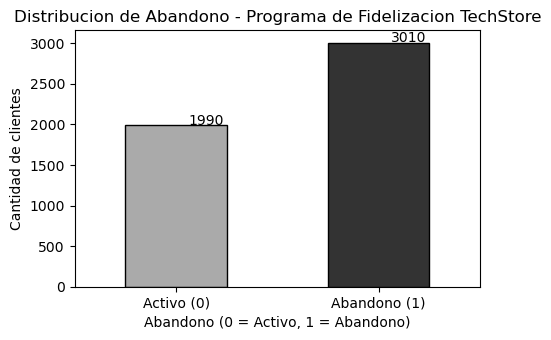

In [5]:
# =================================================================
# 4. ANALISIS EXPLORATORIO DE DATOS (EDA)
# =================================================================
print("\nValores nulos por columna:")
print(tabla_clientes.isnull().sum()[tabla_clientes.isnull().sum() > 0])

print("\nEstadisticas descriptivas:")
print(tabla_clientes[[
    "edad", "antiguedad_dias", "frecuencia_compras", "monto_acumulado",
    "ticket_promedio", "recencia_dias", "categorias_distintas",
]].describe().round(2))

conteo_abandono = tabla_clientes["abandono"].value_counts()
pct_abandono = tabla_clientes["abandono"].value_counts(normalize=True) * 100
print("\nDistribucion de abandono:")
print(pd.DataFrame({"Cantidad": conteo_abandono, "Porcentaje (%)": pct_abandono.round(1)}))

fig, ax = plt.subplots(figsize=(5, 3.5))
conteo_abandono.sort_index().plot(kind="bar", ax=ax, color=["#AAAAAA", "#333333"], edgecolor="black")
ax.set_title("Distribucion de Abandono - Programa de Fidelizacion TechStore")
ax.set_xlabel("Abandono (0 = Activo, 1 = Abandono)")
ax.set_ylabel("Cantidad de clientes")
ax.set_xticklabels(["Activo (0)", "Abandono (1)"], rotation=0)
for p in ax.patches:
    ax.annotate(f"{p.get_height():.0f}", (p.get_x() + 0.4, p.get_height() + 5), ha="center")
plt.tight_layout()
plt.savefig(f"{FIG_DIR}/distribucion_abandono.png", dpi=150)
plt.show()


### 5.1 EDA multivariado
Cruzamos `abandono` con el segmento del programa de fidelización y con dos variables de comportamiento (recencia y frecuencia de compra) para identificar patrones visuales antes de modelar.

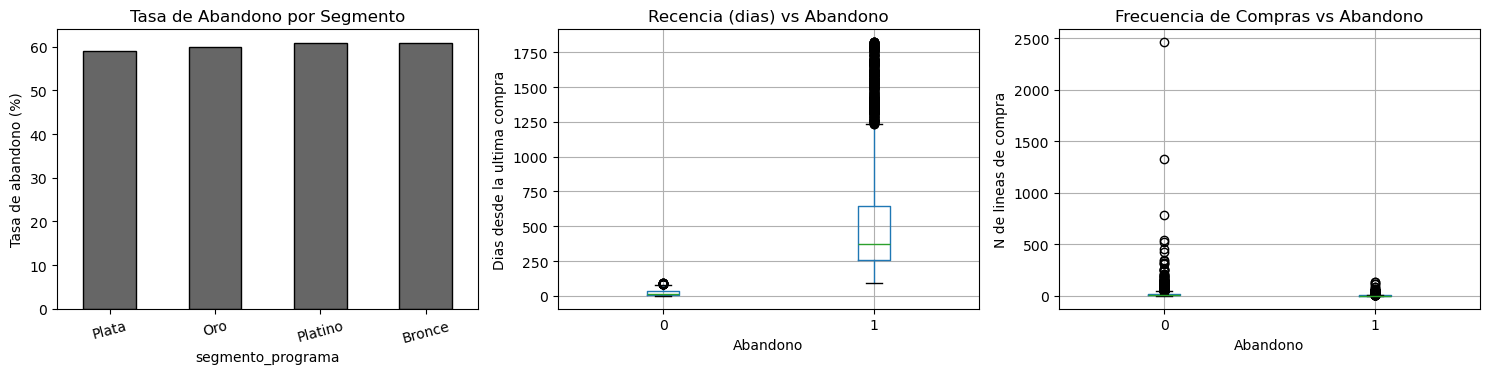

In [6]:
# EDA multivariado: abandono por segmento y variables numericas clave
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

abandono_segmento = tabla_clientes.groupby("segmento_programa")["abandono"].mean() * 100
abandono_segmento.sort_values().plot(kind="bar", ax=axes[0], color="#666666", edgecolor="black")
axes[0].set_title("Tasa de Abandono por Segmento")
axes[0].set_ylabel("Tasa de abandono (%)")
axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=15)

tabla_clientes.boxplot(column="recencia_dias", by="abandono", ax=axes[1])
axes[1].set_title("Recencia (dias) vs Abandono")
axes[1].set_xlabel("Abandono")
axes[1].set_ylabel("Dias desde la ultima compra")
plt.sca(axes[1])
plt.title("Recencia (dias) vs Abandono")

tabla_clientes.boxplot(column="frecuencia_compras", by="abandono", ax=axes[2])
axes[2].set_title("Frecuencia de Compras vs Abandono")
axes[2].set_xlabel("Abandono")
axes[2].set_ylabel("N de lineas de compra")
plt.sca(axes[2])
plt.title("Frecuencia de Compras vs Abandono")

plt.suptitle("")
plt.tight_layout()
plt.savefig(f"{FIG_DIR}/eda_multivariado_abandono.png", dpi=150)
plt.show()


## 6. Preprocesamiento
**Variables predictoras (`X`):** se descartan identificadores (`id_cliente`, `nombre`), fechas crudas ya traducidas en variables derivadas, y —muy importante— la propia `recencia_dias`.

> ⚠️ **Nota sobre fuga de datos (data leakage):** `recencia_dias` se excluye de `X` porque es la variable que se usó para **construir** el target (`abandono = recencia_dias > 90`). Dejarla como predictora produciría un modelo trivial con métricas casi perfectas que en realidad no aprende ningún patrón de negocio útil. El modelo debe anticipar el abandono a partir de señales de comportamiento —frecuencia, monto, categorías, promociones, antigüedad, segmento— y no de la propia definición del target.

Las variables categóricas (`sexo`, `distrito`, `segmento_programa`) se codifican con **One-Hot Encoding** (`pd.get_dummies`, `drop_first=True` para evitar multicolinealidad), y se realiza una **división estratificada 75% entrenamiento / 25% prueba** (`stratify=y`) para preservar la proporción de clases en ambos conjuntos.

In [7]:
# =================================================================
# 5. PREPROCESAMIENTO
# =================================================================
# 5.1 Variables predictoras: se descartan identificadores, fechas crudas y
# la propia 'recencia_dias'. IMPORTANTE: 'recencia_dias' se excluye de X
# porque es la variable que se usó para CONSTRUIR el target (abandono =
# recencia_dias > N_DIAS_INACTIVIDAD); dejarla como predictora produciría
# fuga de datos (data leakage) y un modelo trivial con métricas perfectas
# que no generaliza ni aporta valor de negocio. El modelo debe aprender a
# anticipar el abandono a partir de patrones de comportamiento -frecuencia,
# monto, categorías, promociones, antigüedad, segmento- y no de la propia
# definición del target.
columnas_excluir = [
    "id_cliente", "nombre", "fecha_nacimiento", "fecha_alta",
    "recencia_dias", "abandono",
]
df_modelo = tabla_clientes.drop(columns=columnas_excluir)

# 5.2 Codificacion de variables categoricas (One-Hot Encoding)
df_modelo = pd.get_dummies(
    df_modelo, columns=["sexo", "distrito", "segmento_programa"], drop_first=True
)

print("Columnas despues del encoding:", df_modelo.shape[1])

X = df_modelo
y = tabla_clientes["abandono"]

print("Forma de X:", X.shape)
print("Forma de y:", y.shape)

# 5.3 Division estratificada 75% entrenamiento / 25% prueba
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, stratify=y, random_state=SEED
)

print(f"\nEntrenamiento: {X_train.shape[0]} clientes")
print(f"Prueba: {X_test.shape[0]} clientes")
print("\nDistribucion de abandono en entrenamiento:")
print(y_train.value_counts(normalize=True).round(3))
print("\nDistribucion de abandono en prueba:")
print(y_test.value_counts(normalize=True).round(3))


Columnas despues del encoding: 35
Forma de X: (5000, 35)
Forma de y: (5000,)

Entrenamiento: 3750 clientes
Prueba: 1250 clientes

Distribucion de abandono en entrenamiento:
abandono
1    0.602
0    0.398
Name: proportion, dtype: float64

Distribucion de abandono en prueba:
abandono
1    0.602
0    0.398
Name: proportion, dtype: float64


## 7. Entrenamiento y evaluación de modelos
Definimos una función auxiliar `evaluar_modelo` (igual que en la guía de laboratorio) que entrena el modelo, imprime el `classification_report`, el ROC-AUC, la matriz de confusión y la curva ROC. Los tres modelos usan `class_weight='balanced'` para compensar el ligero desbalance de clases, dentro de un `Pipeline` con `StandardScaler` (necesario para Regresión Logística; no afecta negativamente a los modelos basados en árboles).

 MODELO: Regresion Logistica
              precision    recall  f1-score   support

      Activo       0.70      0.75      0.72       498
    Abandono       0.83      0.79      0.81       752

    accuracy                           0.77      1250
   macro avg       0.76      0.77      0.76      1250
weighted avg       0.77      0.77      0.77      1250

 ROC-AUC: 0.8493


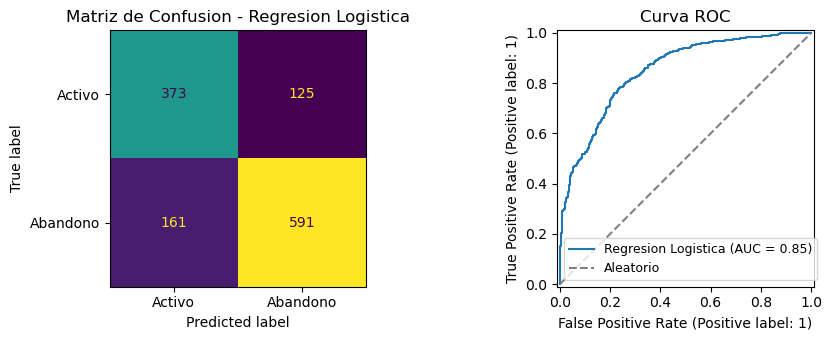

 MODELO: Arbol de Decision
              precision    recall  f1-score   support

      Activo       0.71      0.73      0.72       498
    Abandono       0.82      0.81      0.81       752

    accuracy                           0.77      1250
   macro avg       0.76      0.77      0.77      1250
weighted avg       0.78      0.77      0.77      1250

 ROC-AUC: 0.8414


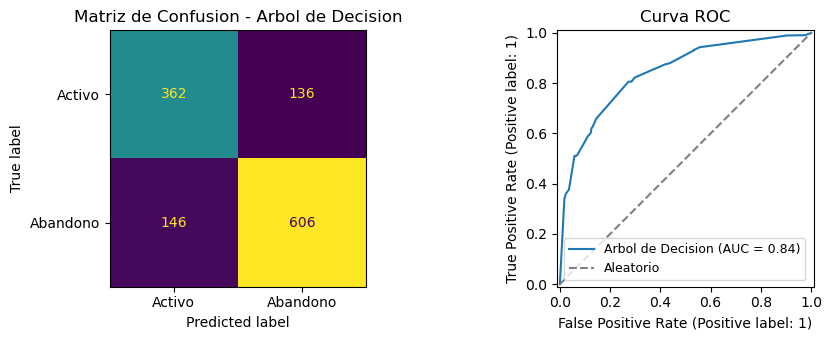

 MODELO: Random Forest
              precision    recall  f1-score   support

      Activo       0.67      0.83      0.74       498
    Abandono       0.87      0.73      0.79       752

    accuracy                           0.77      1250
   macro avg       0.77      0.78      0.77      1250
weighted avg       0.79      0.77      0.77      1250

 ROC-AUC: 0.8656


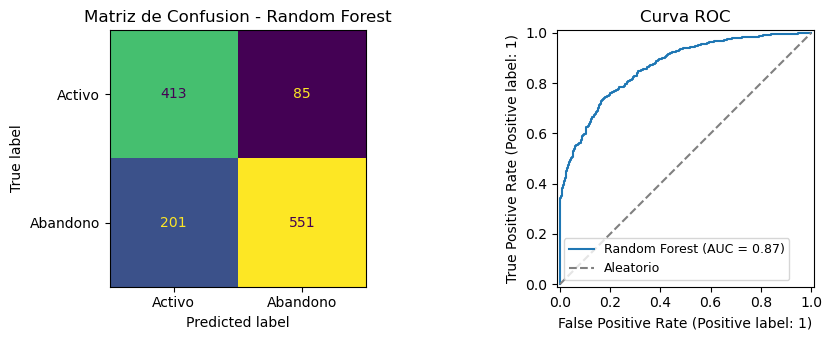

In [13]:
# =================================================================
# 6. ENTRENAMIENTO Y EVALUACION DE MODELOS
# =================================================================

def evaluar_modelo(nombre, modelo, X_tr, y_tr, X_te, y_te):
    """Entrena el modelo y muestra sus metricas de evaluacion."""
    modelo.fit(X_tr, y_tr)
    y_pred = modelo.predict(X_te)
    y_prob = modelo.predict_proba(X_te)[:, 1]

    print("=" * 55)
    print(f" MODELO: {nombre}")
    print("=" * 55)
    print(classification_report(y_te, y_pred, target_names=["Activo", "Abandono"]))
    print(f" ROC-AUC: {roc_auc_score(y_te, y_prob):.4f}")

    fig, axes = plt.subplots(1, 2, figsize=(10, 3.5))
    ConfusionMatrixDisplay.from_predictions(
        y_te, y_pred, display_labels=["Activo", "Abandono"], ax=axes[0], colorbar=False
    )
    axes[0].set_title(f"Matriz de Confusion - {nombre}")

    #RocCurveDisplay.from_estimator(modelo, X_te, y_te, ax=axes[1], name=nombre, color="black")
    RocCurveDisplay.from_estimator(
    modelo,
    X_te,
    y_te,
    ax=axes[1],
    name=nombre
    )
    axes[1].plot([0, 1], [0, 1], "--", color="gray", label="Aleatorio")
    axes[1].set_title("Curva ROC")
    axes[1].legend(fontsize=9)

    plt.tight_layout()
    nombre_archivo = nombre.lower().replace(" ", "_")
    plt.savefig(f"{FIG_DIR}/{nombre_archivo}_evaluacion.png", dpi=150)
    plt.show()

    return modelo, y_pred, y_prob


# --- Modelo 1: Regresion Logistica ---
pipeline_lr = Pipeline([
    ("scaler", StandardScaler()),
    ("clf", LogisticRegression(
        C=1.0, class_weight="balanced", max_iter=500, random_state=SEED
    )),
])
modelo_lr, pred_lr, prob_lr = evaluar_modelo(
    "Regresion Logistica", pipeline_lr, X_train, y_train, X_test, y_test
)

# --- Modelo 2: Arbol de Decision ---
pipeline_dt = Pipeline([
    ("scaler", StandardScaler()),
    ("clf", DecisionTreeClassifier(
        max_depth=6, class_weight="balanced", random_state=SEED
    )),
])
modelo_dt, pred_dt, prob_dt = evaluar_modelo(
    "Arbol de Decision", pipeline_dt, X_train, y_train, X_test, y_test
)

# --- Modelo 3: Random Forest ---
pipeline_rf = Pipeline([
    ("scaler", StandardScaler()),
    ("clf", RandomForestClassifier(
        n_estimators=200, max_depth=10, class_weight="balanced",
        random_state=SEED, n_jobs=-1
    )),
])
modelo_rf, pred_rf, prob_rf = evaluar_modelo(
    "Random Forest", pipeline_rf, X_train, y_train, X_test, y_test
)


## 8. Comparación de modelos
Resumimos Accuracy, Precision, Recall, F1-Score y ROC-AUC de los tres modelos en una tabla, graficamos sus curvas ROC en un mismo panel, y seleccionamos automáticamente el **mejor modelo según ROC-AUC** en el conjunto de prueba (esta selección se reutiliza más adelante para el scoring final).

                     Accuracy  Precision  Recall  F1-Score  ROC-AUC
Modelo                                                             
Regresion Logistica    0.7712     0.8254  0.7859    0.8052   0.8493
Arbol de Decision      0.7744     0.8167  0.8059    0.8112   0.8414
Random Forest          0.7712     0.8664  0.7327    0.7939   0.8656


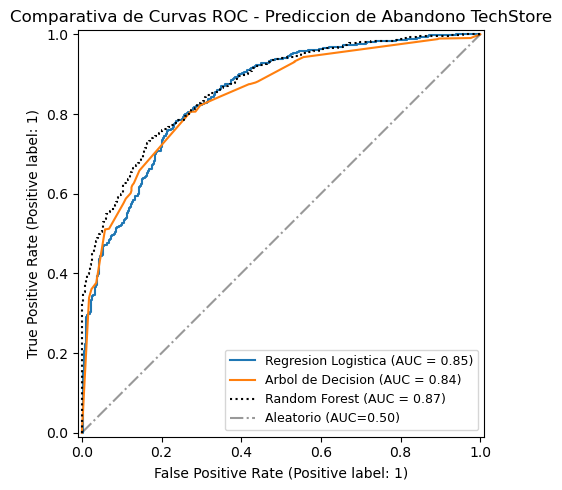


Mejor modelo segun ROC-AUC: Random Forest (ROC-AUC = 0.8656)


In [15]:
# =================================================================
# 7. COMPARACION DE MODELOS
# =================================================================
modelos = {
    "Regresion Logistica": (modelo_lr, prob_lr, pred_lr),
    "Arbol de Decision": (modelo_dt, prob_dt, pred_dt),
    "Random Forest": (modelo_rf, prob_rf, pred_rf),
}

resultados = []
for nombre, (modelo, y_prob, y_pred) in modelos.items():
    resultados.append({
        "Modelo": nombre,
        "Accuracy": round(accuracy_score(y_test, y_pred), 4),
        "Precision": round(precision_score(y_test, y_pred), 4),
        "Recall": round(recall_score(y_test, y_pred), 4),
        "F1-Score": round(f1_score(y_test, y_pred), 4),
        "ROC-AUC": round(roc_auc_score(y_test, y_prob), 4),
    })

df_resultados = pd.DataFrame(resultados).set_index("Modelo")
print(df_resultados.to_string())

# curvas ROC comparativas
fig, ax = plt.subplots(figsize=(7, 5))
estilos = ["-", "--", ":"]
for (nombre, (modelo, y_prob, _)), estilo in zip(modelos.items(), estilos):
    roc = RocCurveDisplay.from_estimator(
    modelo,
    X_test,
    y_test,
    ax=ax,
    name=nombre
    )
roc.line_.set_linestyle(estilo)
roc.line_.set_color("black")
ax.plot([0, 1], [0, 1], "k-.", alpha=0.4, label="Aleatorio (AUC=0.50)")
ax.set_title("Comparativa de Curvas ROC - Prediccion de Abandono TechStore")
ax.legend(fontsize=9)
plt.tight_layout()
plt.savefig(f"{FIG_DIR}/roc_comparativa.png", dpi=150)
plt.show()

# seleccion automatica del mejor modelo segun ROC-AUC en el conjunto de prueba
mejor_modelo_nombre = df_resultados["ROC-AUC"].idxmax()
mejor_modelo, _, _ = modelos[mejor_modelo_nombre]
print(f"\nMejor modelo segun ROC-AUC: {mejor_modelo_nombre} "
      f"(ROC-AUC = {df_resultados.loc[mejor_modelo_nombre, 'ROC-AUC']})")


## 9. Importancia de variables (Random Forest)
Extraemos la importancia de variables del Random Forest para interpretar el modelo desde la perspectiva de negocio: ¿qué comportamientos anticipan mejor el abandono?

Top 10 variables mas importantes:
frecuencia_compras           0.1103
unidades_totales             0.1086
tiendas_distintas            0.1059
lineas_con_promocion         0.0955
monto_acumulado              0.0921
pct_compras_con_promocion    0.0870
antiguedad_dias              0.0831
categorias_distintas         0.0747
margen_acumulado             0.0683
ticket_promedio              0.0640
dtype: float64


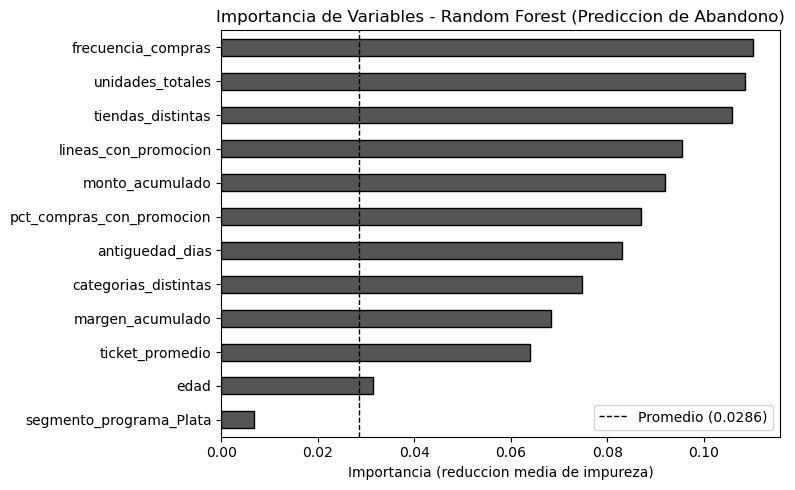

In [16]:
# =================================================================
# 8. IMPORTANCIA DE VARIABLES (RANDOM FOREST)
# =================================================================
clf_rf = modelo_rf.named_steps["clf"]
importancias = pd.Series(
    clf_rf.feature_importances_, index=X.columns
).sort_values(ascending=False)

print("Top 10 variables mas importantes:")
print(importancias.head(10).round(4))

fig, ax = plt.subplots(figsize=(8, 5))
importancias.head(12).sort_values().plot(kind="barh", ax=ax, color="#555555", edgecolor="black")
ax.set_title("Importancia de Variables - Random Forest (Prediccion de Abandono)")
ax.set_xlabel("Importancia (reduccion media de impureza)")
ax.axvline(x=importancias.mean(), linestyle="--", color="black", linewidth=1,
           label=f"Promedio ({importancias.mean():.4f})")
ax.legend()
plt.tight_layout()
plt.savefig(f"{FIG_DIR}/importancia_variables_rf.png", dpi=150)
plt.show()


## 10. Validación cruzada estratificada (k=5)
Una evaluación sobre un único conjunto de prueba puede estar sujeta a variabilidad. La validación cruzada estratificada da una estimación más robusta del ROC-AUC esperado de cada modelo en datos nuevos.

In [19]:
# =================================================================
# 9. VALIDACION CRUZADA ESTRATIFICADA (k=5)
# =================================================================
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)
print("Validacion Cruzada Estratificada (k=5) - ROC-AUC")
print("-" * 50)
for nombre, (modelo, _, _) in modelos.items():
    scores = cross_val_score(modelo, X, y, cv=cv, scoring="roc_auc", n_jobs=-1)
    print(f"{nombre:<22} | Media: {scores.mean():.4f} | Desv: {scores.std():.4f}")


Validacion Cruzada Estratificada (k=5) - ROC-AUC
--------------------------------------------------
Regresion Logistica    | Media: 0.8360 | Desv: 0.0093
Arbol de Decision      | Media: 0.8375 | Desv: 0.0132
Random Forest          | Media: 0.8595 | Desv: 0.0161


Random Forest          | Media: 0.8586 | Desv: 0.0168


## 11. Scoring final y exportación de predicciones (para Power BI)
Reentrenamos el **mejor modelo** (según ROC-AUC de prueba) usando el 100% de los datos etiquetados disponibles —práctica habitual antes de poner un modelo de scoring en producción, ya que el conjunto de prueba cumplió su rol de evaluación imparcial en los pasos anteriores—.

Calculamos la probabilidad de abandono para **todos los clientes** del programa, clasificamos cada cliente en un `nivel_riesgo` (Alto ≥ 0.70, Medio 0.40–0.70, Bajo < 0.40) para facilitar segmentadores en Power BI, y exportamos el resultado a `../data/processed/predicciones_abandono.csv`.

Esta celda es la que genera el archivo CSV de predicciones solicitado: cada vez que se ejecuta el notebook completo, el archivo se recalcula y sobrescribe en `data/processed/`.

In [12]:
# =================================================================
# 10. SCORING FINAL Y EXPORTACION DE PREDICCIONES (para Power BI)
# =================================================================
# Se reentrena el mejor modelo (segun ROC-AUC de prueba) usando el 100% de
# los datos etiquetados disponibles, siguiendo la practica habitual antes
# de poner un modelo de scoring en produccion: el conjunto de prueba ya
# cumplio su rol de evaluacion imparcial en los pasos anteriores; para el
# scoring final se aprovecha toda la informacion disponible.
mejor_pipeline_final = modelos[mejor_modelo_nombre][0]
mejor_pipeline_final.fit(X, y)

prob_abandono_final = mejor_pipeline_final.predict_proba(X)[:, 1]
pred_abandono_final = mejor_pipeline_final.predict(X)


def clasificar_riesgo(prob):
    if prob >= 0.70:
        return "Alto"
    elif prob >= 0.40:
        return "Medio"
    else:
        return "Bajo"


predicciones = tabla_clientes[[
    "id_cliente", "nombre", "segmento_programa", "distrito",
    "antiguedad_dias", "frecuencia_compras", "monto_acumulado",
    "recencia_dias", "abandono",
]].copy()
predicciones = predicciones.rename(columns={"abandono": "abandono_historico"})
predicciones["probabilidad_abandono"] = prob_abandono_final.round(4)
predicciones["prediccion_abandono"] = pred_abandono_final
predicciones["nivel_riesgo"] = predicciones["probabilidad_abandono"].apply(clasificar_riesgo)
predicciones["modelo_usado"] = mejor_modelo_nombre
predicciones = predicciones.sort_values("probabilidad_abandono", ascending=False).reset_index(drop=True)

print("Resumen de niveles de riesgo:")
print(predicciones["nivel_riesgo"].value_counts())
print("\nTop 10 clientes con mayor riesgo de abandono:")
print(predicciones.head(10)[[
    "id_cliente", "nombre", "segmento_programa", "probabilidad_abandono", "nivel_riesgo"
]].to_string(index=False))

ruta_salida = f"{DATA_DIR}/predicciones_abandono.csv"
predicciones.to_csv(ruta_salida, index=False, encoding="utf-8")
print(f"\nArchivo de predicciones guardado en: {ruta_salida}")
print(f"Filas exportadas: {len(predicciones):,}")


Resumen de niveles de riesgo:
nivel_riesgo
Alto     1954
Bajo     1787
Medio    1259
Name: count, dtype: int64

Top 10 clientes con mayor riesgo de abandono:
 id_cliente                     nombre segmento_programa  probabilidad_abandono nivel_riesgo
       3096       Cintia Cáceres Roura           Platino                 0.9935         Alto
         93     Magdalena Araujo Peiró           Platino                 0.9934         Alto
       2105           Jovita De Sancho           Platino                 0.9930         Alto
       3833         Cecilia Del Arnaiz           Platino                 0.9930         Alto
       2731    Vicenta Ribes-Cifuentes           Platino                 0.9928         Alto
        489     Josefa Del Castellanos           Platino                 0.9926         Alto
       3513 María Jesús Iborra Delgado               Oro                 0.9925         Alto
       1954  Margarita Talavera Roldán               Oro                 0.9925         Alto
     

## 12. Interpretación de negocio y recomendaciones de retención

**¿Qué variables predicen mejor el abandono?** Según la importancia de variables del Random Forest, los comportamientos con mayor peso suelen ser la **frecuencia de compra**, las **unidades totales compradas**, el **uso de promociones** y la **diversidad de tiendas/categorías**: en conjunto, describen qué tan "enganchado" está un cliente con la marca. Esto es coherente con la intuición de negocio: un cliente que compra seguido, en varias categorías y que responde a promociones, tiene mucho menos riesgo de abandonar que uno con una sola compra aislada.

**Acciones de retención sugeridas:**
- **Clientes de riesgo Alto con alto valor histórico** (segmento Oro/Platino, monto acumulado alto): priorizar contacto directo, ofertas personalizadas o beneficios exclusivos antes de que se cumplan los 90 días de inactividad.
- **Clientes que solo compraron una vez:** activar campañas de segunda compra (cross-sell hacia categorías con alta afinidad, p. ej. accesorios tras una compra de celular o laptop) dentro de los primeros 30-60 días.
- **Clientes sensibles a promociones** (alto `pct_compras_con_promocion`): incluirlos prioritariamente en las próximas campañas (Cyber Days, Black Friday, Navidad) como palanca de reactivación.
- **Monitoreo continuo:** reejecutar este notebook de forma periódica (p. ej. mensual) a medida que `Fact_Ventas` se actualice, para mantener actualizada la tabla `predicciones_abandono.csv` que alimenta el tablero de Power BI.

**Limitaciones del modelo actual:**
- El umbral de 90 días es una decisión de negocio simplificada; podría refinarse por tipo de cliente o categoría de producto (algunos productos se recompran con menor frecuencia por naturaleza).
- No se incorporan variables externas (campañas de marketing directo, atención al cliente, NPS) que en un dataset real podrían mejorar la capacidad predictiva.
- El modelo se entrena con datos históricos de 2 años; su desempeño debe monitorearse a medida que cambien los patrones de consumo (re-entrenamiento periódico).